In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from itertools import product

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset,delete_dataset

In [4]:
from scipy import stats

In [5]:
DATA_ROOT = Path(os.environ["EPHEMERAL"]) / "pyspoc_synthetic_data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

In [ ]:
def gaussians_on_grid_subset(n_samples, n_features, n_points_per_side=3, spacing=1.0, glob_gaussian_scale=0.1, gaussian_scale_sigma = None, seed=None):
    
    rng = np.random.default_rng(seed)
    n_points_on_grid = max(2, int(np.sqrt(n_samples)))
    
    # if too few, just set acc to num features. might need to be tuned
    if n_points_per_side < 10 and n_features < 10:
        if n_points_per_side ** n_features < n_points_on_grid:
            n_points_on_grid = n_points_per_side ** n_features
    
    # print(f'subsampling {n_points_on_grid} grid centers on the {n_features} hypercube')
    grid_centers = np.empty((0, n_features), dtype=np.int64)
    while len(grid_centers) < n_points_on_grid:
        extra = rng.integers(0, n_points_per_side, size=(n_points_on_grid - len(grid_centers), n_features))
        grid_centers = np.unique(np.vstack([grid_centers, extra]), axis=0)

    y = rng.permutation(np.arange(n_samples) % n_points_on_grid)
    
    # either have iid gaussians with a global scale    
    if gaussian_scale_sigma is None:
        X = grid_centers[y] * spacing + rng.normal(scale=glob_gaussian_scale, size=(n_samples, n_features))        
    # or vary the scale at each gaussian at each point
    else:
        per_gaussian_scale = glob_gaussian_scale * rng.lognormal(0, gaussian_scale_sigma, size=(n_points_on_grid, n_features))
        X = grid_centers[y] * spacing + rng.normal(size=(n_samples, n_features)) * per_gaussian_scale[y]        

    return X, y,n_points_on_grid

subsampling 31 grid centers on the 10000 hypercube


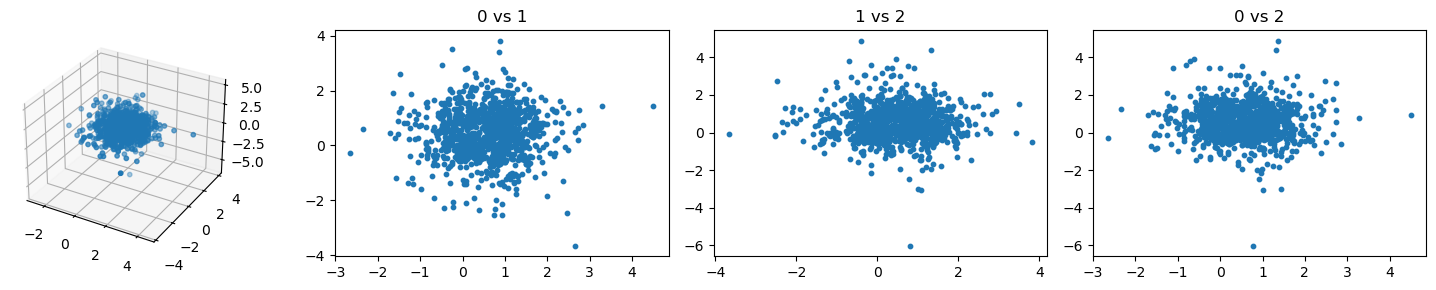

In [69]:
X,y = gaussians_on_grid_subset(n_samples=1000, n_features=10000,n_points_per_side=2,spacing=1.0, glob_gaussian_scale=0.5, gaussian_scale_sigma = 0.5, seed=None)
plot_3d_scatters(X,title_name='')

In [74]:
# delete_dataset('isotropic_gauss_hypercube_grid',root=DATA_ROOT)

In [76]:
category_lst = ['density']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
random_seeds_lst = [30,2679]

spacing_val = 1.0
n_pt_per_side_lst = [2,4,6,8]
glob_scale_lst = [0.1,0.2,0.5]
per_cluster_scale_lst = [None,0.1,0.5,1]

for n_samples, n_features in product(n_samples_lst, n_features_lst):
            
    for per_cluster_scale in per_cluster_scale_lst:
        
        if per_cluster_scale == None:
            data_gen_name = 'isotropic_gauss_hypercube_grid'
        else:
            data_gen_name = 'anisotropic_gauss_hypercube_grid'

        print(n_samples, n_features,data_gen_name)

        for n_pt_per_side in n_pt_per_side_lst:
            
            for glob_scale in glob_scale_lst:
                
                    for sample_num,seed in enumerate(random_seeds_lst):
                        
                        X,y,num_sampled_pts = gaussians_on_grid_subset(n_samples=n_samples, n_features=n_features,n_points_per_side=n_pt_per_side,
                                                    spacing=spacing_val, glob_gaussian_scale=glob_scale, gaussian_scale_sigma =per_cluster_scale, seed=seed)
                        
                        params_dict = {
                            'num_points_per_side' : n_pt_per_side,
                            'spacing_val' : spacing_val,
                            'glob_gaussian_scale' : glob_scale,
                            'gaussian_scale_sigma' : per_cluster_scale,
                            'num_sampled_points_on_grid' : num_sampled_pts
                        }
                        
                        extra_arr = {
                            'hypercube_labels' : y
                        }
                                        
                        try:
                            save_dataset(X, 
                                        generator=data_gen_name,
                                        params=params_dict,
                                        seed=seed,
                                        category=category_lst,
                                        extra_arrays=extra_arr, 
                                        root=DATA_ROOT)

                        except:
                            print('error?')

1000 10 isotropic_gauss_hypercube_grid
1000 10 anisotropic_gauss_hypercube_grid
1000 10 anisotropic_gauss_hypercube_grid
1000 10 anisotropic_gauss_hypercube_grid
1000 100 isotropic_gauss_hypercube_grid
1000 100 anisotropic_gauss_hypercube_grid
1000 100 anisotropic_gauss_hypercube_grid
1000 100 anisotropic_gauss_hypercube_grid
1000 1000 isotropic_gauss_hypercube_grid
1000 1000 anisotropic_gauss_hypercube_grid
1000 1000 anisotropic_gauss_hypercube_grid
1000 1000 anisotropic_gauss_hypercube_grid
1000 10000 isotropic_gauss_hypercube_grid
1000 10000 anisotropic_gauss_hypercube_grid
1000 10000 anisotropic_gauss_hypercube_grid
1000 10000 anisotropic_gauss_hypercube_grid
10000 10 isotropic_gauss_hypercube_grid
10000 10 anisotropic_gauss_hypercube_grid
10000 10 anisotropic_gauss_hypercube_grid
10000 10 anisotropic_gauss_hypercube_grid
10000 100 isotropic_gauss_hypercube_grid
10000 100 anisotropic_gauss_hypercube_grid
10000 100 anisotropic_gauss_hypercube_grid
10000 100 anisotropic_gauss_hypercu

(72, 8)


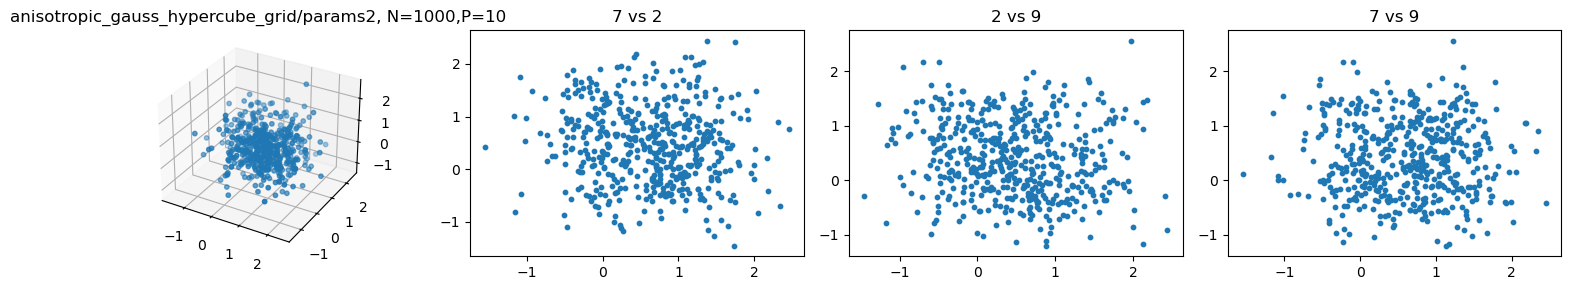

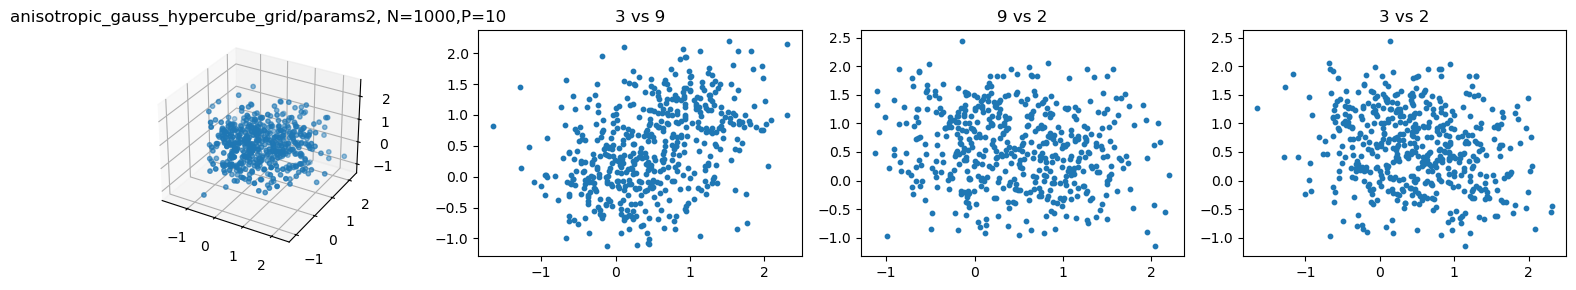

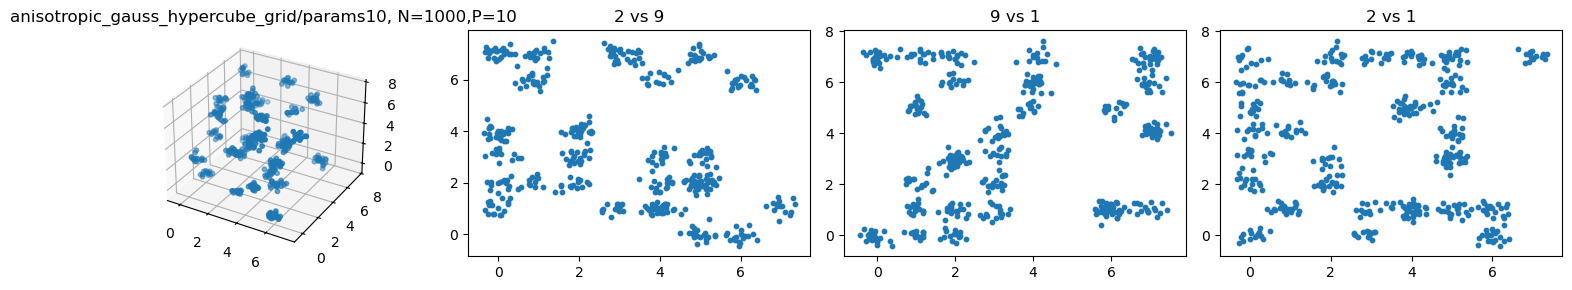

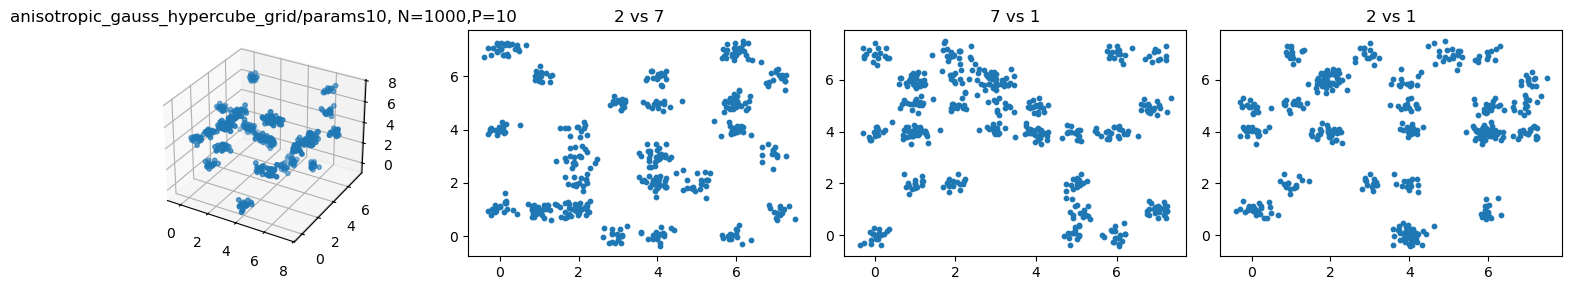

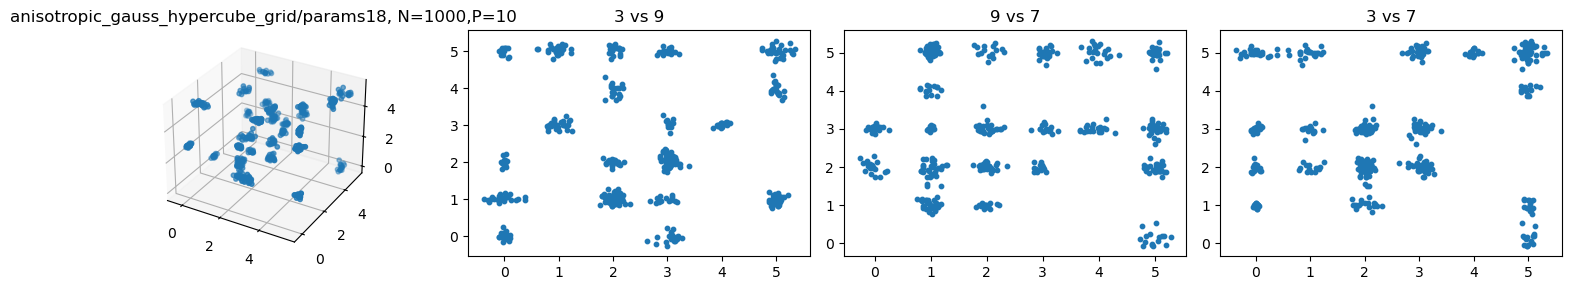

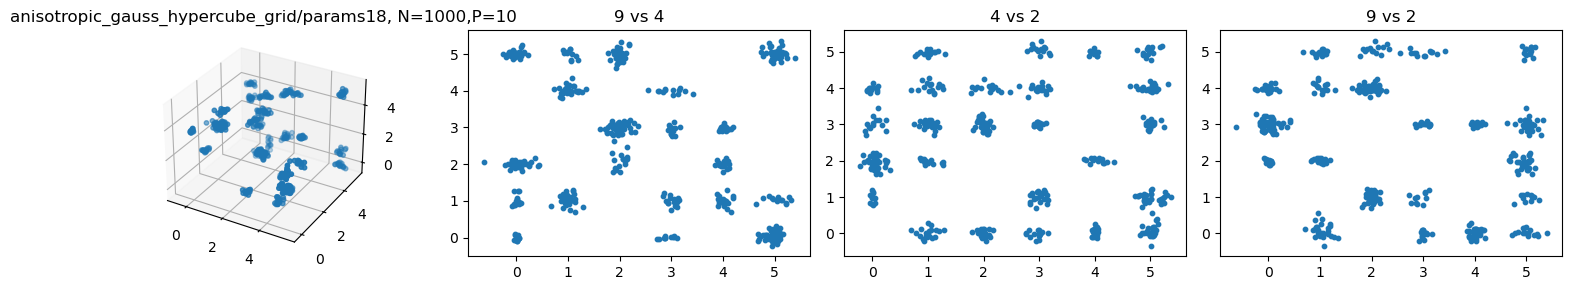

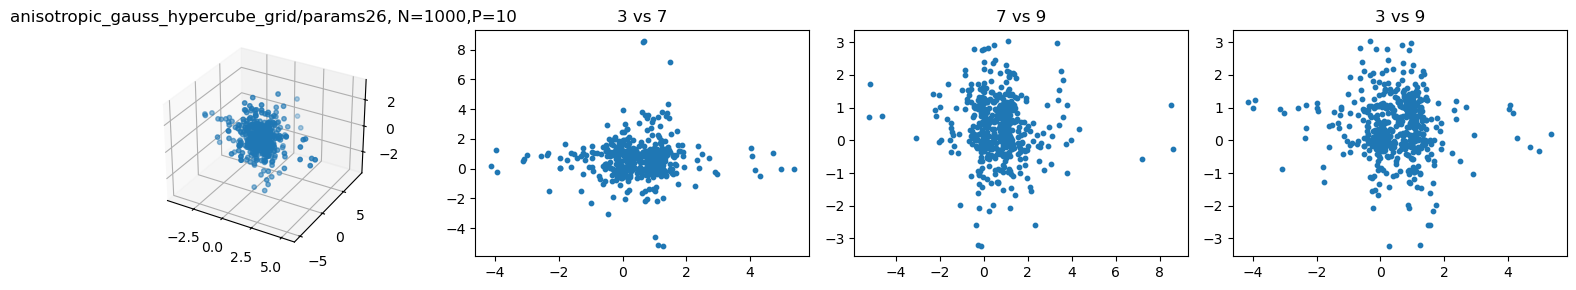

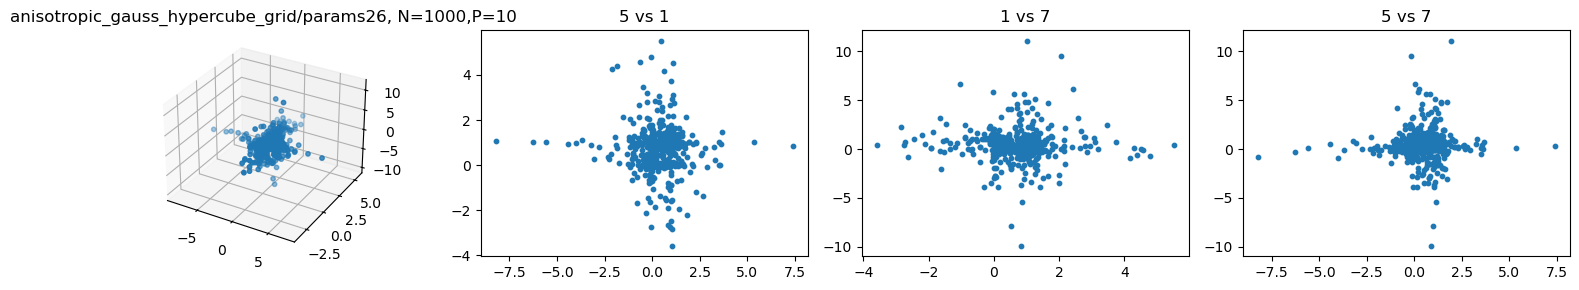

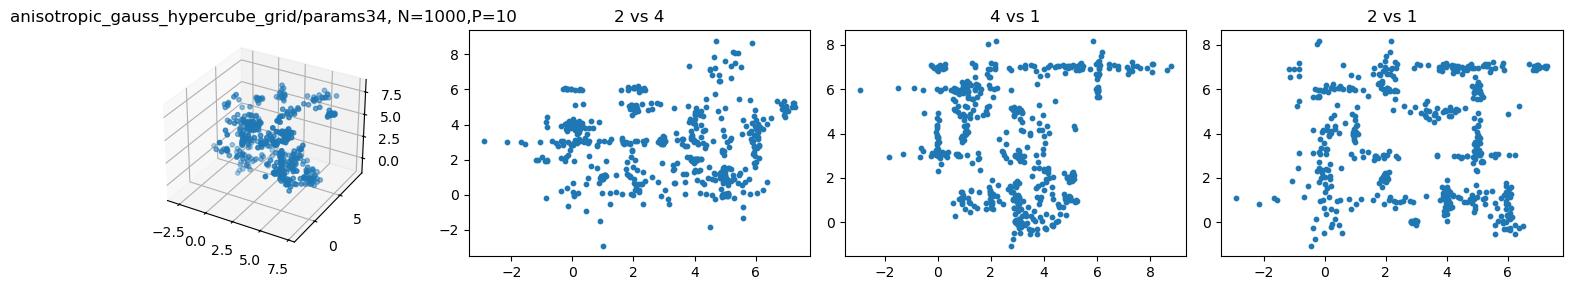

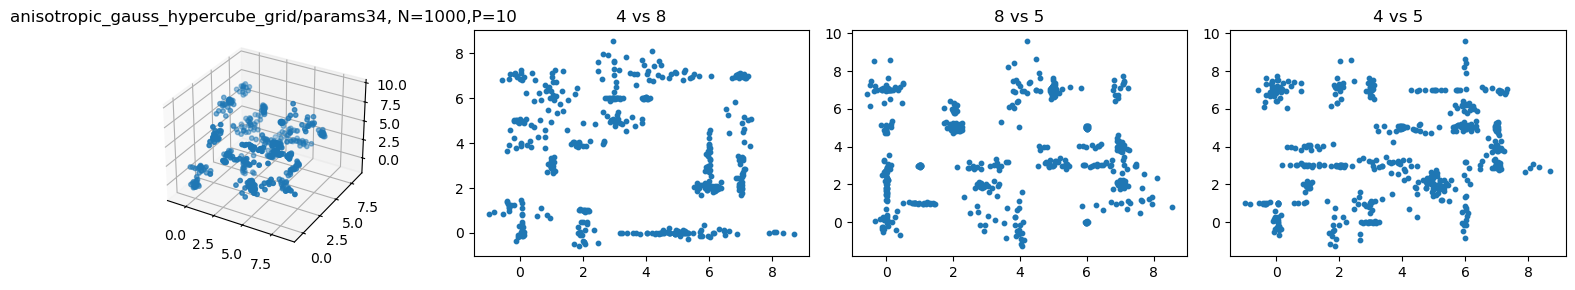

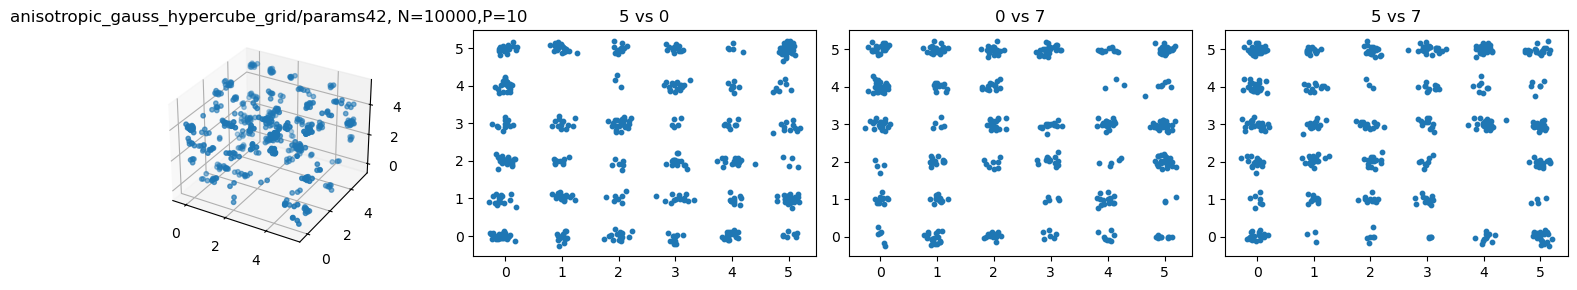

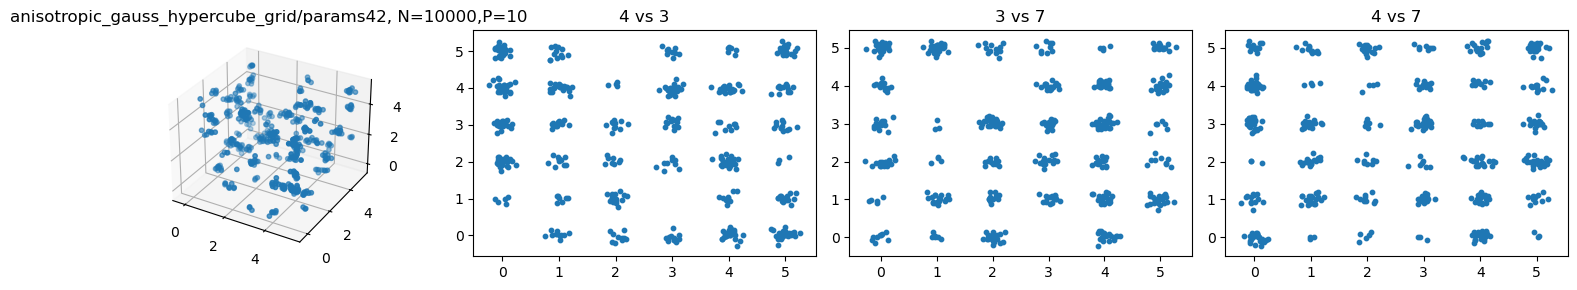

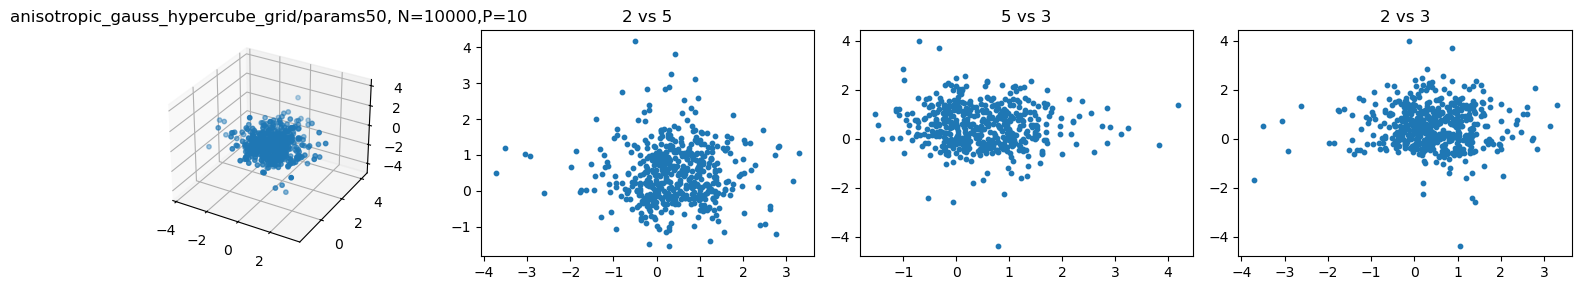

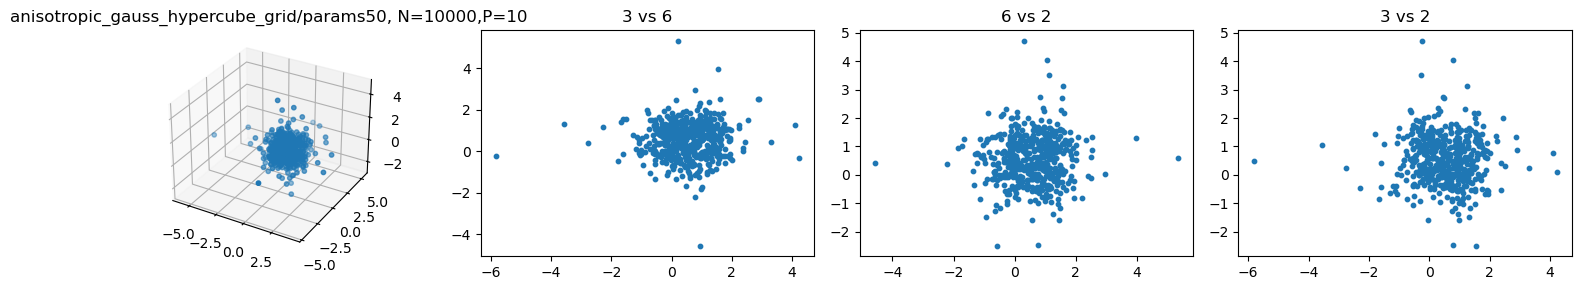

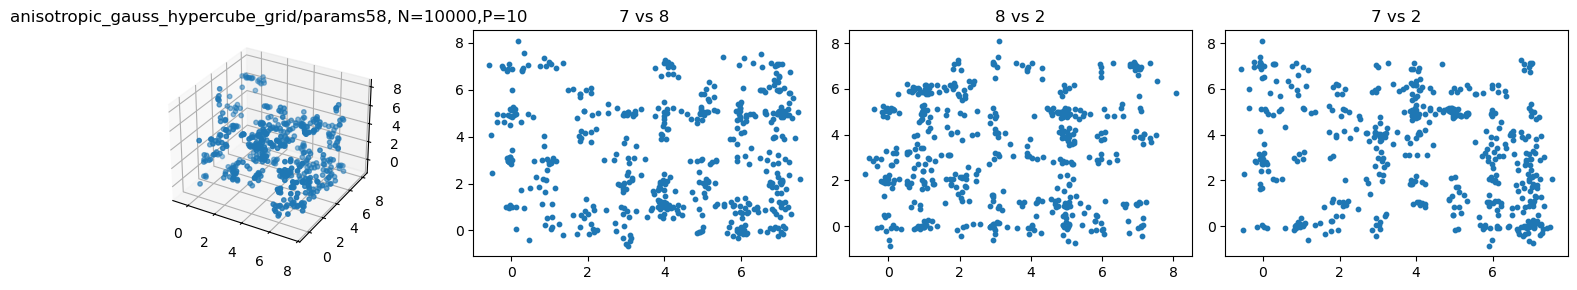

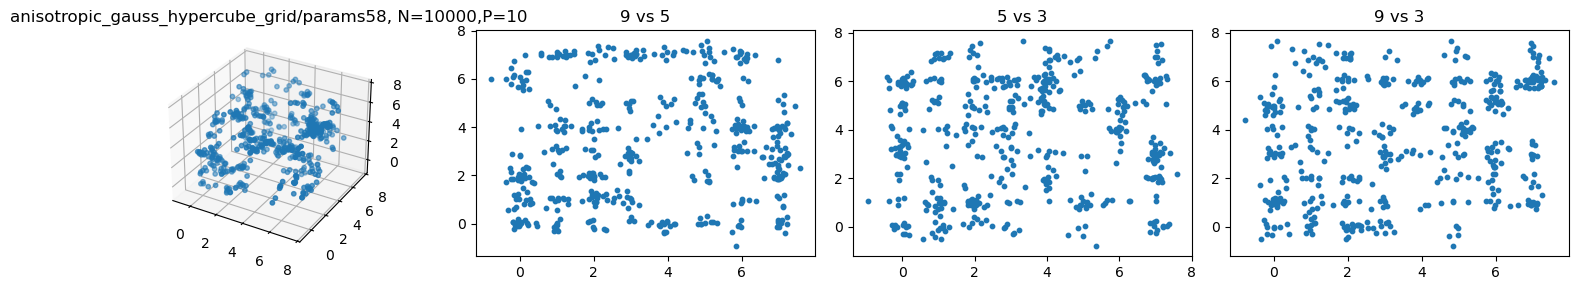

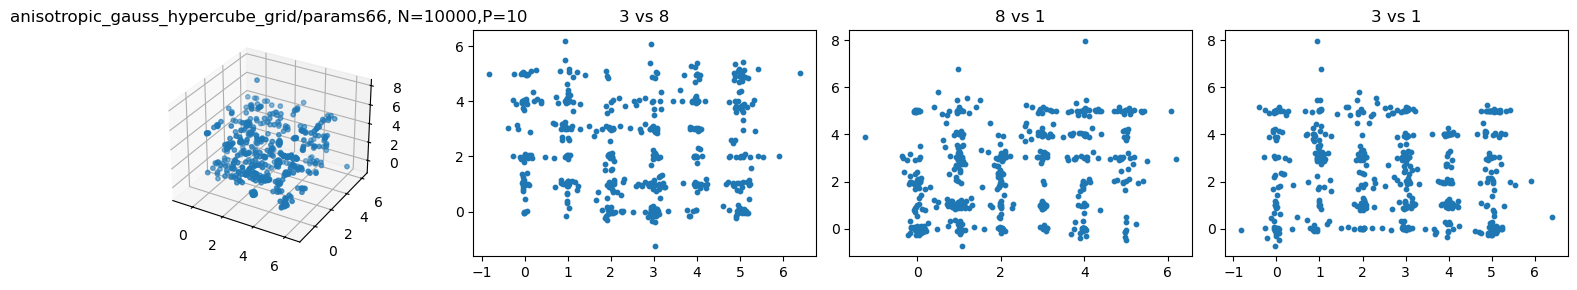

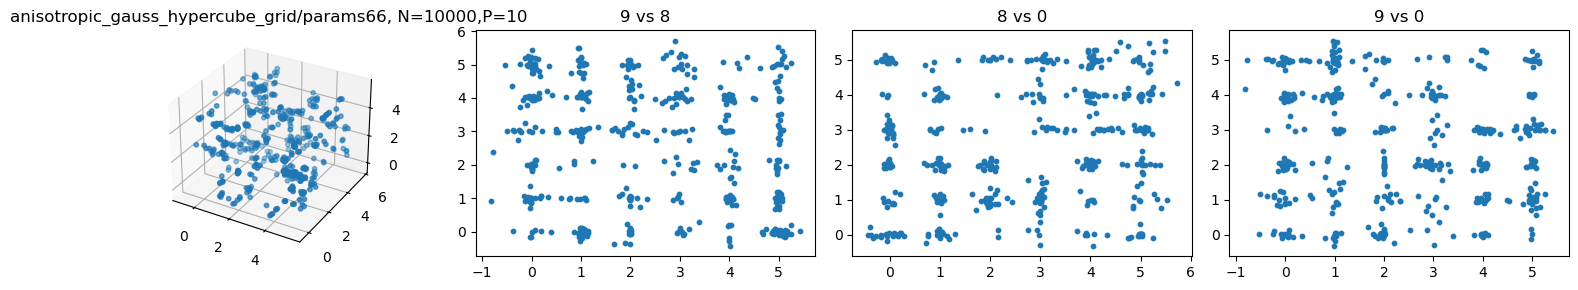

In [77]:
m = pd.read_csv(DATA_ROOT / "manifest.csv")

generator = data_gen_name
params_lst = [f'params{i}' for i in range(0,100) if i%8==2]
m = m[(m.generator == generator) & (m.params_id.isin(params_lst))]
print(m.shape)

max_pts = 500
for r in m.groupby(["generator", "params_id"]).head(2).itertuples():
    X = np.load(DATA_ROOT / f"{r.dataset_id}.npy")
    if len(X) > max_pts:
        rng = np.random.default_rng(0)       
        X = X[rng.choice(len(X), max_pts, replace=False)]
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}",custom_inx=np.random.choice(r.n_cols, 3, replace=False))